In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBRegressor
from xgboost import XGBClassifier

from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix


In [2]:
df=pd.read_csv('loan_data.csv')

Echamos un vistazo a los datos de las primeras columnas.

In [3]:
df.head()

,age,gender,education,income,yrs_exp,ownership,amount,purpose,int_rate,percent_income,cred_hist_length,risk_score,previous_loans,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


Utilizo .info() para comprobar que los tipos de datos coincidan con .head()

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               45000 non-null  float64
 1   gender            45000 non-null  object 
 2   education         45000 non-null  object 
 3   income            45000 non-null  float64
 4   yrs_exp           45000 non-null  int64  
 5   ownership         45000 non-null  object 
 6   amount            45000 non-null  float64
 7   purpose           44962 non-null  object 
 8   int_rate          45000 non-null  float64
 9   percent_income    45000 non-null  float64
 10  cred_hist_length  45000 non-null  float64
 11  risk_score        45000 non-null  int64  
 12  previous_loans    45000 non-null  object 
 13  loan_status       45000 non-null  int64  
dtypes: float64(6), int64(3), object(5)
memory usage: 4.8+ MB


Me percato que hay un valor mal escrito en gender y en ownership. Lo corrijo. (De hecho el "OWN" de ownership es por un espacio, y por ese detalle el modelo lo relacionaba con ese target de esa muestra, obteniendo un accuracy del 1.0. Overfitting por data leakage).

In [5]:
df['gender'].value_counts()

gender
male      24841
female    20158
femal         1
Name: count, dtype: int64

In [6]:
df['ownership'].value_counts()

ownership
RENT        23443
MORTGAGE    18489
OWN          2950
OTHER         117
OWN             1
Name: count, dtype: int64

In [7]:
df['gender'].replace('femal','female',inplace=True)

/tmp/ipykernel_7478/3971679093.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gender'].replace('femal','female',inplace=True)


In [8]:
df['ownership'] = df['ownership'].str.strip().str.upper()

Vamos a comprobar si hay nulos.

In [9]:
res=(df.isna().sum()/len(df))*100
res

age                 0.000000
gender              0.000000
education           0.000000
income              0.000000
yrs_exp             0.000000
ownership           0.000000
amount              0.000000
purpose             0.084444
int_rate            0.000000
percent_income      0.000000
cred_hist_length    0.000000
risk_score          0.000000
previous_loans      0.000000
loan_status         0.000000
dtype: float64

En purpose hay un 0.08% de nulos. Como son pocos y de tipo categorico inputaré con la moda.

In [10]:
moda=df['purpose'].mode()
df['purpose']=df['purpose'].fillna(moda[0])

Utilizo la siguiente función para encontrar los outliers.

In [11]:
def comprobar_outliers_numericos():
    df_numericas=df.select_dtypes(exclude=['object'])

    columnas_num=df_numericas.columns
    col_con_outliers=[]
    for col in columnas_num:
        valores=df[col].values
        Q1,Q3=np.percentile(valores,[25,75])
        IQR=Q3-Q1
        limite_inferior=Q1-1.5*IQR
        limite_superior=Q3+1.5*IQR

        mascara= (valores > limite_superior)|(limite_inferior>valores)
        outliers=valores[mascara]

        mascara_superior=valores > limite_superior
        outliers_superiores=valores[mascara_superior]

        mascara_inferior=valores<limite_inferior
        outliers_inferiores=valores[mascara_inferior]

        col_con_outliers.append(col)
        if(len(outliers)!=0):
            out_sup=(len(outliers_superiores)/len(outliers))*100
            out_inf=(len(outliers_inferiores)/len(outliers))*100
            res=(len(outliers)/len(valores))*100
            print(f"{col} => {res:.2f}% son outliers de los cuales SUPERIORES => {out_sup:.2f}% INFERIORES => {out_inf:.2f}%")
comprobar_outliers_numericos()

age => 4.86% son outliers de los cuales SUPERIORES => 100.00% INFERIORES => 0.00%
income => 4.93% son outliers de los cuales SUPERIORES => 100.00% INFERIORES => 0.00%
yrs_exp => 3.83% son outliers de los cuales SUPERIORES => 100.00% INFERIORES => 0.00%
amount => 5.22% son outliers de los cuales SUPERIORES => 100.00% INFERIORES => 0.00%
int_rate => 0.28% son outliers de los cuales SUPERIORES => 100.00% INFERIORES => 0.00%
percent_income => 1.65% son outliers de los cuales SUPERIORES => 100.00% INFERIORES => 0.00%
cred_hist_length => 3.04% son outliers de los cuales SUPERIORES => 100.00% INFERIORES => 0.00%
risk_score => 1.04% son outliers de los cuales SUPERIORES => 1.71% INFERIORES => 98.29%
loan_status => 22.22% son outliers de los cuales SUPERIORES => 100.00% INFERIORES => 0.00%


Utilizo la siguiente función para inputar la mediana en las columnas: age, income, yrs_exp, amount, int_rate, percent_income, cre_hist

In [ ]:
def inputar_mediana_num(df_temp,col):
    mediana=df_temp[col].median()
    valores=df_temp[col]
    Q1,Q3=np.percentile(valores,[25,75])
    IQR=Q3-Q1
    limite_inferior=Q1-1.5*IQR
    limite_superior=Q3+1.5*IQR
    condicion_mascara= (valores > limite_superior)|(limite_inferior>valores)
    df_temp[col]=np.where(condicion_mascara,mediana,df_temp[col])
inputar_mediana_num(df,'age')
inputar_mediana_num(df,'income')
inputar_mediana_num(df,'yrs_exp')
inputar_mediana_num(df,'amount')
inputar_mediana_num(df,'int_rate')
inputar_mediana_num(df,'percent_income')
inputar_mediana_num(df,'cred_hist_length')



In [13]:
df_cat=df.select_dtypes(include='object')
df_num=df.select_dtypes(exclude='object')

Utilizo "get_dummies" para localizar posibles datos categoricos que estén mal escritos.

In [14]:
dummies=pd.get_dummies(df,prefix='d-',dtype="float")

In [15]:
dummies.isna().sum()

age                     0
income                  0
yrs_exp                 0
amount                  0
int_rate                0
percent_income          0
cred_hist_length        0
risk_score              0
loan_status             0
d-_female               0
d-_male                 0
d-_Associate            0
d-_Bachelor             0
d-_Doctorate            0
d-_High School          0
d-_Master               0
d-_MORTGAGE             0
d-_OTHER                0
d-_OWN                  0
d-_RENT                 0
d-_DEBTCONSOLIDATION    0
d-_EDUCATION            0
d-_HOMEIMPROVEMENT      0
d-_MEDICAL              0
d-_PERSONAL             0
d-_VENTURE              0
d-_No                   0
d-_Yes                  0
dtype: int64

In [16]:
dummies.head()

,age,income,yrs_exp,amount,int_rate,percent_income,cred_hist_length,risk_score,loan_status,d-_female,...,d-_OWN,d-_RENT,d-_DEBTCONSOLIDATION,d-_EDUCATION,d-_HOMEIMPROVEMENT,d-_MEDICAL,d-_PERSONAL,d-_VENTURE,d-_No,d-_Yes
0,22.0,71948.0,0.0,8000.0,16.02,0.12,3.0,561,1,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,21.0,12282.0,0.0,1000.0,11.14,0.08,2.0,504,0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,25.0,12438.0,3.0,5500.0,12.87,0.12,3.0,635,1,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,23.0,79753.0,0.0,8000.0,15.23,0.12,2.0,675,1,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,24.0,66135.0,1.0,8000.0,14.27,0.12,4.0,586,1,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


Preparo el nombre de las columnas que voy a codificar y escalar para pasarlar al preprocesador.

In [ ]:

#Clasificacion:
df_temp=df.drop(columns=['loan_status'])
df_categorical_cols = df_temp.select_dtypes(include=['object'])

#OneHotEncoder

col_cat_sin_educa= df_categorical_cols.drop(columns=['education']).columns

#OrdinalEncoder

col_education=df_categorical_cols[['education']].columns




numeric_cols = df_temp.select_dtypes(exclude=['object']).columns

numeric_cols_sin_risck=df_num.drop(columns=['risk_score']).columns

col_educacion=df_temp[['education']]
df_num=df_temp.select_dtypes(exclude=['object'])

Utilizo este preprocesador para codificar con onehotencoder los datos categóricos que no muestran un orden. utilizo ordinalEncoder para codificar education, que si muestra una orden de niveles de estudios y por último escalaré los datos categoricos. 

Por último, en una pipline, le pasaré los datos procesados y entrenaré un modelo RandomForestClassifier, el cual considero que es idoneo porque es resistente a los outliers.

In [82]:
col_cat_sin_educa=['gender','ownership','purpose','previous_loans']
col_educa=['education']
preprocesador = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), col_cat_sin_educa),
        ('num',StandardScaler(),numeric_cols),
        ('ord',OrdinalEncoder(),col_educacion.columns)
    ],
    remainder='passthrough'
)
pipeline_clasificador=Pipeline([("prep",preprocesador),
    ("model",RandomForestClassifier(n_estimators=50,random_state=65))])

preparo X e y para hacer el split.

In [84]:
y=df['loan_status']
X=df.drop(columns=['loan_status'])


In [85]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=588)

Preparo el X e y para el modelo de regresión (está más adelante).

In [87]:
X_regresion=df.drop(columns=['risk_score'])
y_regresion=df['risk_score']

In [88]:
X_train_regresion,X_test_regresion,y_train_regresion,y_test_regresion=train_test_split(X_regresion,y_regresion,test_size=0.2,random_state=588)

Entreno el modelo de regresión.

In [89]:
pipeline_clasificador.fit(X_train,y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Preparo el preprocesador y la pipline que se encargará de escalar, codificar y preparar el modelo de regresión. Utilizo XGBRegressor como modelo de regresión.

In [90]:
col_cat=['gender','ownership','purpose','previous_loans']
col_educa=['education']
col_num=['income', 'amount','loan_status']

preprocesador_2 = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), col_cat),
        ('ord',OrdinalEncoder(),col_educa),
        ('scl',StandardScaler(),col_num)
    ],
    remainder='drop'
)
pipeline_prediccion=Pipeline([("prep",preprocesador_2),("model",XGBRegressor(
        max_depth=6,
        learning_rate=0.05,
        n_estimators=300,
        subsample=0.8,
        colsample_bytree=0.8))])

Entreno el modelo de regresión.

In [91]:
pipeline_prediccion.fit(X_train_regresion,y_train_regresion)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('ord', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Realizo un test al modelo de clasificación, me da una acierto de 0.926, precision 0.94|0.88, recall 0.97|0.77, f1-score 0.95|0.82.

In [92]:
y_pred = pipeline_clasificador.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9261111111111111
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      7007
           1       0.88      0.77      0.82      1993

    accuracy                           0.93      9000
   macro avg       0.91      0.87      0.89      9000
weighted avg       0.92      0.93      0.92      9000



Realizo una matriz de confusión para comprobar los falsos positivos, falsos negativos, verdaderos positivos y verdaderos negativos.

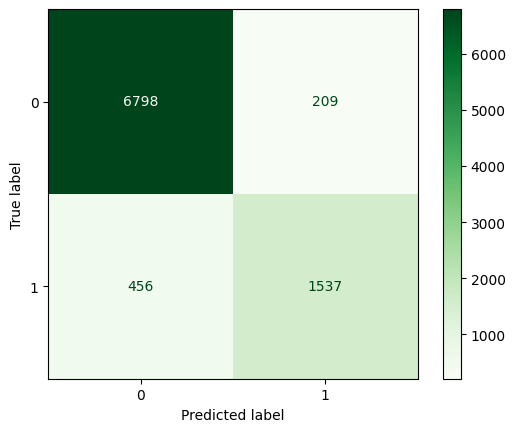

In [93]:
ConfusionMatrixDisplay.from_estimator(pipeline_clasificador, X_test, y_test, cmap='Greens')

Aquí plasmo un resumen de los datos anteriores y añado la curva ROC AUC que da un 0.9718, eso indica que el modelo es muy fiable.

In [94]:
y_pred = pipeline_clasificador.predict(X_test)

y_prob = pipeline_clasificador.predict_proba(X_test)[:, 1]


print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9261111111111111
ROC AUC: 0.9718118237579209
Confusion Matrix:
 [[6798  209]
 [ 456 1537]]


En el modelo de regresión me da un R2 muy malo, pero es debido a que las caracteristicas en este dataset tiene una correlación muy débil con el risk_score (es el target a predecir). Por tanto es esperable que tenga un R2 malo.

In [ ]:
y_pred = pipeline_prediccion.predict(X_test_regresion)

r2 = r2_score(y_test_regresion, y_pred)

print("R2:", r2)

MAE: 40.47370910644531
R2: -0.9252994060516357


Mediante el modelo de clasificación ya entrenado, obtengo las caracteristicas más importantes.

In [104]:
importancias = pipeline_clasificador.named_steps["model"].feature_importances_

feature_names = pipeline_clasificador.named_steps["prep"].get_feature_names_out()

df_importancias = pd.DataFrame({
    'feature': feature_names,
    'importance': importancias
}).sort_values(by='importance', ascending=False)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(df_importancias)

                         feature  importance
9        cat__previous_loans_Yes    0.230263
14                 num__int_rate    0.157653
15           num__percent_income    0.149607
11                   num__income    0.131009
13                   num__amount    0.060811
17               num__risk_score    0.058622
3            cat__ownership_RENT    0.052659
10                      num__age    0.030123
12                  num__yrs_exp    0.027243
16         num__cred_hist_length    0.025314
18                ord__education    0.017621
5   cat__purpose_HOMEIMPROVEMENT    0.010143
2             cat__ownership_OWN    0.009311
4         cat__purpose_EDUCATION    0.008206
0               cat__gender_male    0.008199
8           cat__purpose_VENTURE    0.008009
6           cat__purpose_MEDICAL    0.008006
7          cat__purpose_PERSONAL    0.006761
1           cat__ownership_OTHER    0.000441
